In [4]:
import os
import pandas as pd
import json
import joblib

import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, fbeta_score
import numpy as np

In [5]:
DATA_DIR = os.path.join("..", "data", "processed", "splits")
RESULTS_DIR = os.path.join("..", "data", "processed", "results")

X_train = pd.read_csv(os.path.join(DATA_DIR, "X_train_lr.csv"))
y_train = pd.read_csv(os.path.join(DATA_DIR, "y_train.csv"))
X_test = pd.read_csv(os.path.join(DATA_DIR, "X_test_lr.csv"))
y_test = pd.read_csv(os.path.join(DATA_DIR, "y_test.csv"))

In [6]:
base_lr = LogisticRegression(random_state=42, max_iter=1000)
base_lr.fit(X_train, y_train.squeeze())

LogisticRegression(max_iter=1000, random_state=42)

In [7]:
param_grid = {
    "C": np.logspace(-4, 4, 20),
    "penalty": ["l1", "l2", "elasticnet"],
    "solver": ["saga"],
    "l1_ratio": [0.0, 0.25, 0.5, 0.75, 1.0],  # only used when penalty='elasticnet'
    "class_weight": [None, "balanced"],
    "max_iter": [500, 1000, 2000]
}

lr = RandomizedSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_distributions=param_grid,
    n_iter=100,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

lr.fit(X_train, y_train.squeeze())

Fitting 5 folds for each of 100 candidates, totalling 500 fits


c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(


RandomizedSearchCV(cv=5, estimator=LogisticRegression(random_state=42),
                   n_iter=100, n_jobs=-1,
                   param_distributions={'C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
                                        'class_weight': [None, 'balanced'],
                                        'l1_ratio': [0.0, 0.25, 0.5, 0.75, 1.0],
                                        'max_iter': [500, 1000, 2000],
                                        'penalty': ['l1', 'l2', 'elasticnet'],
                                        'solver': ['saga']},
                   random_state=42, scoring='roc_auc', verbose=2)

In [8]:
best_lr = lr.best_estimator_
print("Best Score:", lr.best_score_)
print("Best Hyperparameters:", lr.best_params_)

Best Score: 0.9011624325042046
Best Hyperparameters: {'solver': 'saga', 'penalty': 'l1', 'max_iter': 500, 'l1_ratio': 0.25, 'class_weight': 'balanced', 'C': np.float64(0.615848211066026)}


In [9]:
y_preds_base = base_lr.predict(X_test)
y_preds = best_lr.predict(X_test)

print("\n--- Base LR ---")
print("Accuracy:", accuracy_score(y_test.squeeze(), y_preds_base))
print("F2 Score:", fbeta_score(y_test.squeeze(), y_preds_base, beta=2))
print(classification_report(y_test.squeeze(), y_preds_base))
print("ROC-AUC:", roc_auc_score(y_test.squeeze(), base_lr.predict_proba(X_test)[:, 1]))
print("Confusion Matrix:\n", confusion_matrix(y_test.squeeze(), y_preds_base))

print("\n--- Tuned LR ---")
print("Accuracy:", accuracy_score(y_test.squeeze(), y_preds))
print("F2 Score:", fbeta_score(y_test.squeeze(), y_preds, beta=2))
print(classification_report(y_test.squeeze(), y_preds))
print("ROC-AUC:", roc_auc_score(y_test.squeeze(), best_lr.predict_proba(X_test)[:, 1]))
print("Confusion Matrix:\n", confusion_matrix(y_test.squeeze(), y_preds))


--- Base LR ---
Accuracy: 0.8186813186813187
F2 Score: 0.8695652173913043
              precision    recall  f1-score   support

           0       0.85      0.73      0.79        83
           1       0.80      0.89      0.84        99

    accuracy                           0.82       182
   macro avg       0.82      0.81      0.81       182
weighted avg       0.82      0.82      0.82       182

ROC-AUC: 0.9133503711816965
Confusion Matrix:
 [[61 22]
 [11 88]]

--- Tuned LR ---
Accuracy: 0.8241758241758241
F2 Score: 0.8517034068136272
              precision    recall  f1-score   support

           0       0.82      0.78      0.80        83
           1       0.83      0.86      0.84        99

    accuracy                           0.82       182
   macro avg       0.82      0.82      0.82       182
weighted avg       0.82      0.82      0.82       182

ROC-AUC: 0.9124984787635391
Confusion Matrix:
 [[65 18]
 [14 85]]


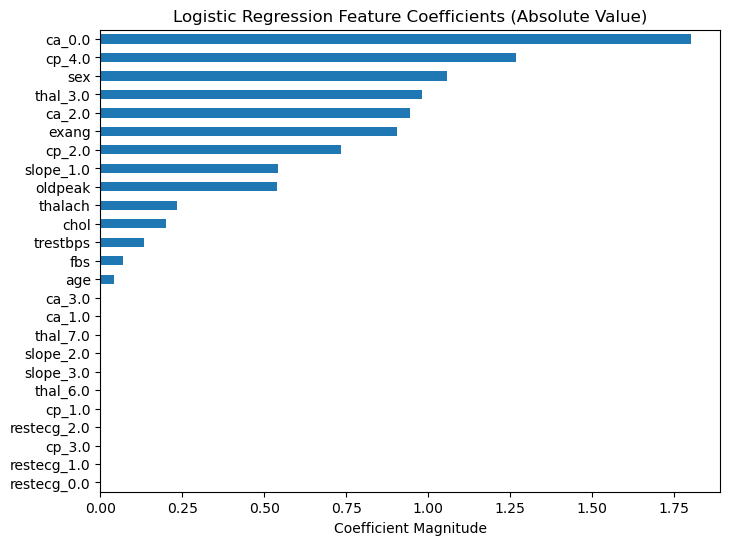

In [10]:
coefficients = pd.Series(np.abs(best_lr.coef_[0]), index=X_train.columns)
coefficients.sort_values().plot(kind='barh', figsize=(8, 6))
plt.title('Logistic Regression Feature Coefficients (Absolute Value)')
plt.xlabel('Coefficient Magnitude')
plt.show()

In [11]:
joblib.dump(best_lr, '../models/logistic_regression.pkl')

lr_results = {
    'base_lr': {
        'accuracy': float(accuracy_score(y_test.squeeze(), y_preds_base)),
        'roc_auc': float(roc_auc_score(y_test.squeeze(), base_lr.predict_proba(X_test)[:, 1])),
        'f2': float(fbeta_score(y_test.squeeze(), y_preds_base, beta=2))
    },
    'tuned_lr': {
        'accuracy': float(accuracy_score(y_test.squeeze(), y_preds)),
        'roc_auc': float(roc_auc_score(y_test.squeeze(), best_lr.predict_proba(X_test)[:, 1])),
        'f2': float(fbeta_score(y_test.squeeze(), y_preds, beta=2))
    }
}

with open(os.path.join(RESULTS_DIR, 'lr_results.json'), 'w') as f:
    json.dump(lr_results, f, indent=4)